# 01 — Fabry–Pérot Cavity

## Classical cavity model: resonance, transmission, buildup, linewidth and losses

---

## Goal

We will build a classical model of a two-mirror Fabry–Pérot cavity.

We will study:

1. Cavity parameters
2. Resonance condition
3. Airy transmission function
4. Intracavity power
5. Cavity buildup
6. Output power
7. Finesse
8. Free spectral range (FSR)
9. Linewidth
10. Mirror losses
11. Symmetric and asymmetric cavities
12. Parameter sweeps
13. Numerical vs analytical comparison

### Important distinction

A passive Fabry–Pérot cavity does **not** provide optical gain in the laser/OPO sense.

It provides **intracavity power buildup** because the circulating fields interfere constructively at resonance.

We define the buildup factor as

$$
B = \frac{P_{\rm cav}}{P_{\rm in}}.
$$

This is different from nonlinear optical gain. That distinction will become important when we introduce the nonlinear crystal.

# 1. Define the cavity parameters

We begin with a simple symmetric, lossless cavity.

The main parameters are:

- $L$ — cavity length
- $\lambda$ — optical wavelength
- $P_{\rm in}$ — incident optical power
- $R_1,R_2$ — mirror power reflectivities
- $T_1,T_2$ — mirror power transmissions

For ideal lossless mirrors,

$$
R_i+T_i=1.
$$

We first use a symmetric cavity:

$$
R_1=R_2=R.
$$

Later we will allow $R_1\neq R_2$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Speed of light
c = 299_792_458.0  # m/s

# Cavity parameters
L = 1.0                 # cavity length [m]
wavelength = 1064e-9    # wavelength [m]
P_in = 1.0              # input power [W]

# Symmetric cavity
R1 = 0.99
R2 = 0.99

# Lossless mirrors
T1 = 1 - R1
T2 = 1 - R2

print(f'Cavity length       = {L:.3f} m')
print(f'Wavelength          = {wavelength*1e9:.1f} nm')
print(f'Input power         = {P_in:.3f} W')
print(f'Mirror 1: R1={R1:.5f}, T1={T1:.5f}')
print(f'Mirror 2: R2={R2:.5f}, T2={T2:.5f}')

Cavity length       = 1.000 m
Wavelength          = 1064.0 nm
Input power         = 1.000 W
Mirror 1: R1=0.99000, T1=0.01000
Mirror 2: R2=0.99000, T2=0.01000


# 2. Resonance condition

Light travels a round-trip distance of

$$
2L.
$$

The round-trip phase is

$$
\phi=\frac{4\pi\nu L}{c}.
$$

Resonance occurs when

$$
\phi=2\pi m,
$$

where $m$ is an integer.

Therefore,

$$
2L=m\lambda
$$

and the resonant frequencies are

$$
\nu_m=\frac{mc}{2L}.
$$

The spacing between adjacent resonances is the free spectral range:

$$
\boxed{\mathrm{FSR}=\frac{c}{2L}}.
$$

In [2]:
FSR = c / (2 * L)

print(f'Free Spectral Range = {FSR/1e6:.6f} MHz')

Free Spectral Range = 149.896229 MHz


# 3. Airy function / cavity transmission

The circulating field is the sum of the fields from repeated round trips:

$$
E_{\rm cav}
=
t_1E_{\rm in}
\left[
1+r_1r_2e^{-i\phi}
+(r_1r_2e^{-i\phi})^2+\cdots
\right].
$$

This is a geometric series, giving

$$
\boxed{
E_{\rm cav}
=
\frac{t_1E_{\rm in}}
{1-r_1r_2e^{-i\phi}}
}.
$$

Using

$$
r_i=\sqrt{R_i},
\qquad
t_i=\sqrt{T_i},
$$

the intracavity power buildup is

$$
\boxed{
\frac{P_{\rm cav}}{P_{\rm in}}
=
\frac{T_1}
{1+R_1R_2-2\sqrt{R_1R_2}\cos\phi}
}.
$$

The transmitted power is

$$
P_{\rm out}=T_2P_{\rm cav},
$$

so

$$
\boxed{
\frac{P_{\rm out}}{P_{\rm in}}
=
\frac{T_1T_2}
{1+R_1R_2-2\sqrt{R_1R_2}\cos\phi}
}.
$$

In [3]:
def cavity_buildup(phi, R1, R2, T1):
    """Intracavity power buildup factor."""
    denominator = (
        1
        + R1 * R2
        - 2 * np.sqrt(R1 * R2) * np.cos(phi)
    )
    return T1 / denominator


def cavity_transmission(phi, R1, R2, T1, T2):
    """Cavity power transmission P_out / P_in."""
    denominator = (
        1
        + R1 * R2
        - 2 * np.sqrt(R1 * R2) * np.cos(phi)
    )
    return T1 * T2 / denominator


# One free spectral range: phi from -pi to +pi
phi = np.linspace(-np.pi, np.pi, 5000)

B = cavity_buildup(phi, R1, R2, T1)

transmission = cavity_transmission(
    phi, R1, R2, T1, T2
)

# 4. Airy transmission plot

We plot the transmitted power over one free spectral range.

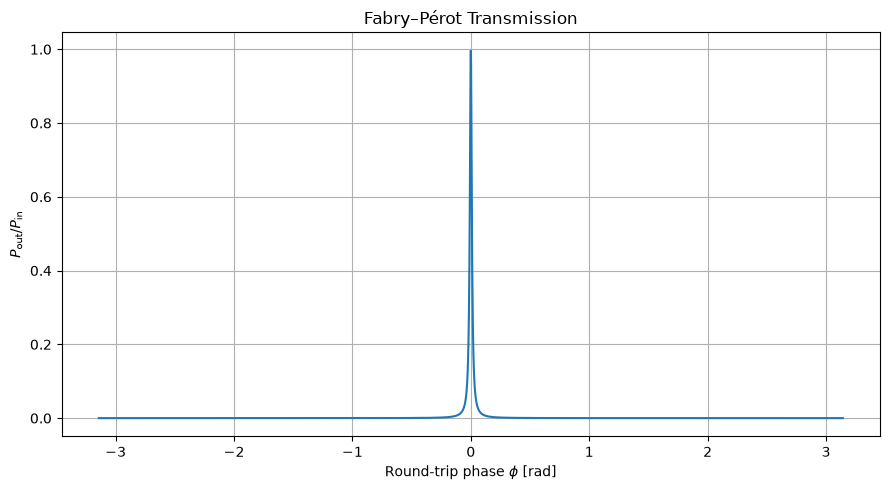

In [4]:
plt.figure(figsize=(9, 5))

plt.plot(phi, transmission)

plt.xlabel(r'Round-trip phase $\phi$ [rad]')
plt.ylabel(r'$P_{\rm out}/P_{\rm in}$')
plt.title('Fabry–Pérot Transmission')

plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Intracavity power buildup

The buildup factor is

$$
B=\frac{P_{\rm cav}}{P_{\rm in}}.
$$

For a high-reflectivity cavity, the intracavity power can be much larger than the incident power.

This happens because the field makes many round trips and the contributions add coherently at resonance.

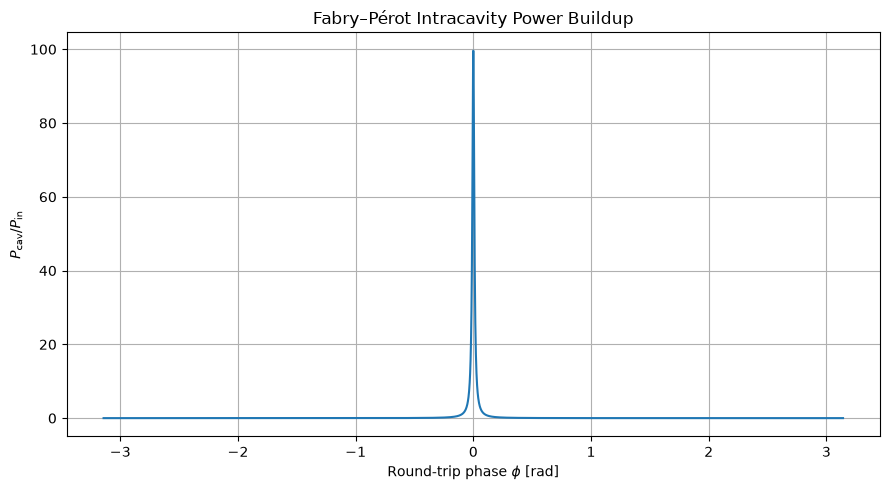

In [5]:
plt.figure(figsize=(9, 5))

plt.plot(phi, B)

plt.xlabel(r'Round-trip phase $\phi$ [rad]')
plt.ylabel(r'$P_{\rm cav}/P_{\rm in}$')
plt.title('Fabry–Pérot Intracavity Power Buildup')

plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Resonant intracavity buildup

At resonance,

$$
\phi=2\pi m,
$$

so $\cos\phi=1$.

Therefore,

$$
\boxed{
B_{\rm res}
=
\frac{T_1}
{(1-\sqrt{R_1R_2})^2}
}.
$$

For a symmetric lossless cavity,

$$
R_1=R_2=R,
\qquad T_1=1-R,
$$

giving

$$
\boxed{
B_{\rm res}=\frac{1}{1-R}
}.
$$

In [6]:
B_res_analytical = (
    T1 / (1 - np.sqrt(R1 * R2))**2
)

B_res_numerical = np.max(B)

print(f'Analytical resonant buildup = {B_res_analytical:.6f}')
print(f'Numerical resonant buildup   = {B_res_numerical:.6f}')
print(
    f'Difference                   = '
    f'{abs(B_res_analytical - B_res_numerical):.3e}'
)

Analytical resonant buildup = 100.000000
Numerical resonant buildup   = 99.610530
Difference                   = 3.895e-01


# 7. Intracavity power

Once the buildup factor is known,

$$
P_{\rm cav}=BP_{\rm in}.
$$

At resonance,

$$
\boxed{
P_{\rm cav,res}=B_{\rm res}P_{\rm in}
}.
$$

In [7]:
P_cav_res = B_res_analytical * P_in

print(f'Input power                = {P_in:.6f} W')
print(f'Resonant intracavity power = {P_cav_res:.6f} W')

Input power                = 1.000000 W
Resonant intracavity power = 100.000000 W


# 8. Output / transmitted power

The transmitted power through mirror 2 is

$$
P_{\rm out}=T_2P_{\rm cav}.
$$

For a symmetric lossless cavity, on resonance,

$$
\frac{P_{\rm out}}{P_{\rm in}}=1.
$$

Therefore the transmitted power equals the incident power even though the intracavity power may be much larger.

This is not a violation of energy conservation: the cavity stores energy temporarily and eventually releases it through the mirrors.

In [8]:
P_out_res = T2 * P_cav_res

print(f'Resonant intracavity power = {P_cav_res:.6f} W')
print(f'Resonant output power      = {P_out_res:.6f} W')
print(f'Output / input             = {P_out_res/P_in:.6f}')

Resonant intracavity power = 100.000000 W
Resonant output power      = 1.000000 W
Output / input             = 1.000000


# 9. Cavity buildup versus mirror reflectivity

For a symmetric lossless cavity,

$$
B_{\rm res}=\frac{1}{1-R}.
$$

Increasing the mirror reflectivity therefore increases the intracavity buildup.

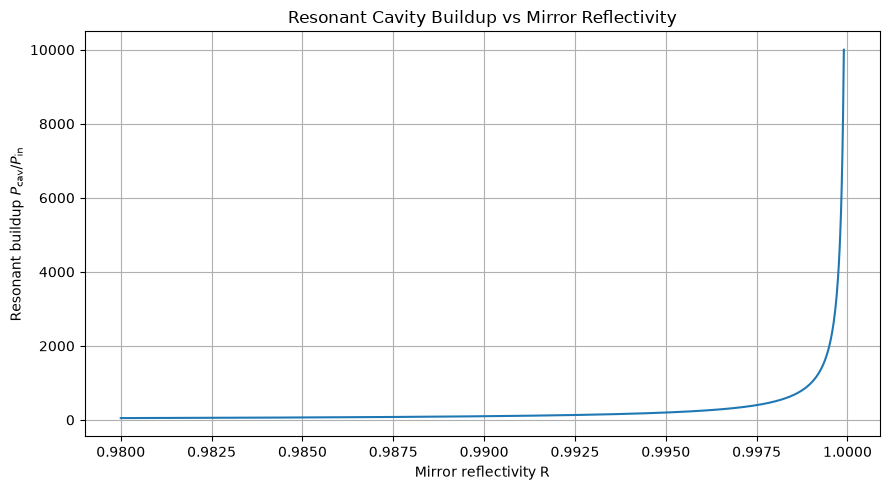

In [11]:
R_values = np.linspace(0.98, 0.9999, 1000)
B_res_values = 1 / (1 - R_values)

plt.figure(figsize=(9, 5))
plt.plot(R_values, B_res_values)

plt.xlabel('Mirror reflectivity R')
plt.ylabel(r'Resonant buildup $P_{\rm cav}/P_{\rm in}$')
plt.title('Resonant Cavity Buildup vs Mirror Reflectivity')

plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Example buildup values

In [12]:
example_R = np.array([
    0.90,
    0.95,
    0.99,
    0.999,
    0.9999
])

example_B = 1 / (1 - example_R)

for R, Bval in zip(example_R, example_B):
    print(f'R = {R:.4f}  ->  B_res = {Bval:.1f}')

R = 0.9000  ->  B_res = 10.0
R = 0.9500  ->  B_res = 20.0
R = 0.9900  ->  B_res = 100.0
R = 0.9990  ->  B_res = 1000.0
R = 0.9999  ->  B_res = 10000.0


# 11. Finesse

For a symmetric high-reflectivity cavity, the approximate finesse is

$$
\boxed{
\mathcal{F}\approx\frac{\pi\sqrt{R}}{1-R}
}.
$$

Higher mirror reflectivity produces higher finesse and sharper resonances.

In [13]:
def finesse_symmetric(R):
    return np.pi * np.sqrt(R) / (1 - R)


F = finesse_symmetric(R1)

print(f'Finesse = {F:.6f}')

Finesse = 312.584522


# 12. Finesse versus reflectivity

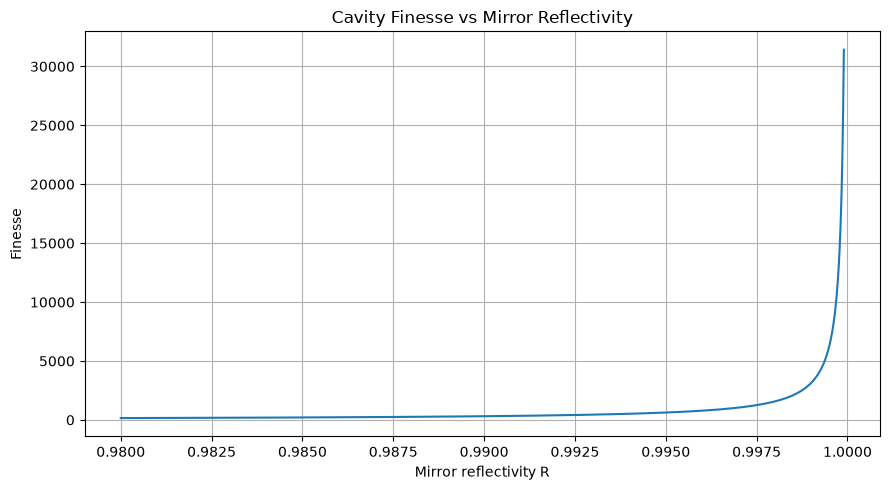

In [14]:
finesse_values = finesse_symmetric(R_values)

plt.figure(figsize=(9, 5))
plt.plot(R_values, finesse_values)

plt.xlabel('Mirror reflectivity R')
plt.ylabel('Finesse')
plt.title('Cavity Finesse vs Mirror Reflectivity')

plt.grid(True)
plt.tight_layout()
plt.show()

# 13. Free Spectral Range

The free spectral range is

$$
\boxed{\mathrm{FSR}=\frac{c}{2L}}.
$$

FSR depends on cavity length, not mirror reflectivity.

A longer cavity has a smaller FSR.

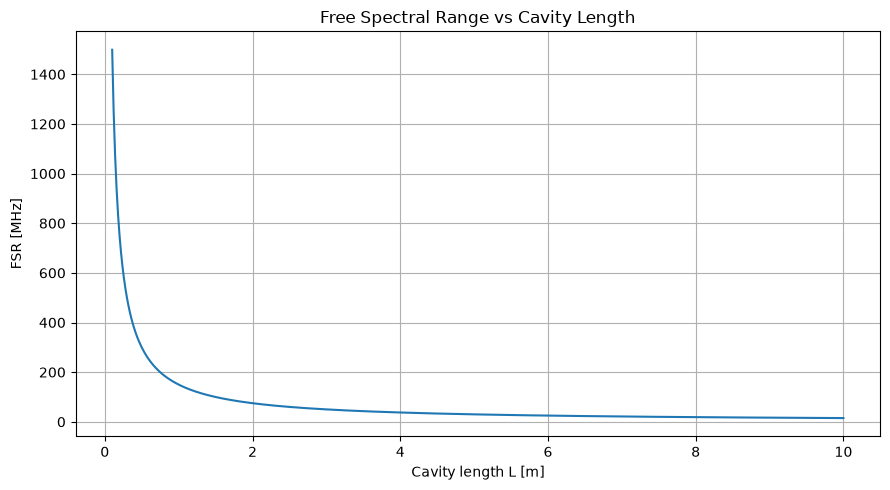

In [15]:
L_values = np.linspace(0.1, 10, 500)
FSR_values = c / (2 * L_values)

plt.figure(figsize=(9, 5))
plt.plot(L_values, FSR_values / 1e6)

plt.xlabel('Cavity length L [m]')
plt.ylabel('FSR [MHz]')
plt.title('Free Spectral Range vs Cavity Length')

plt.grid(True)
plt.tight_layout()
plt.show()

# 14. Cavity linewidth

The cavity linewidth is approximately

$$
\boxed{
\Delta\nu=\frac{\mathrm{FSR}}{\mathcal{F}}
}.
$$

For a symmetric high-finesse cavity,

$$
\Delta\nu
\approx
\frac{c(1-R)}{2\pi L\sqrt{R}}.
$$

Thus higher reflectivity gives narrower linewidth.

In [16]:
linewidth = FSR / F

print(f'FSR       = {FSR/1e6:.6f} MHz')
print(f'Finesse   = {F:.6f}')
print(f'Linewidth = {linewidth:.6f} Hz')
print(f'Linewidth = {linewidth/1e3:.6f} kHz')

FSR       = 149.896229 MHz
Finesse   = 312.584522
Linewidth = 479538.231469 Hz
Linewidth = 479.538231 kHz


# 15. Linewidth versus reflectivity

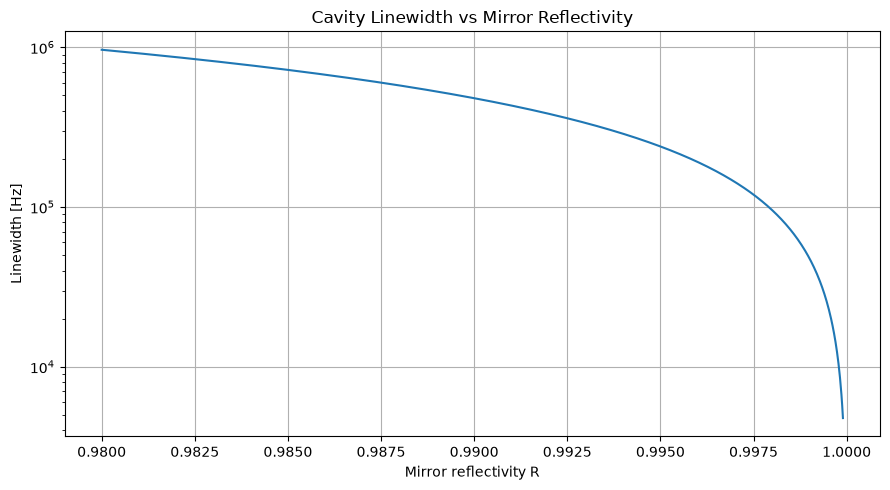

In [17]:
linewidth_values = FSR / finesse_values

plt.figure(figsize=(9, 5))
plt.semilogy(R_values, linewidth_values)

plt.xlabel('Mirror reflectivity R')
plt.ylabel('Linewidth [Hz]')
plt.title('Cavity Linewidth vs Mirror Reflectivity')

plt.grid(True)
plt.tight_layout()
plt.show()

# 16. Frequency-domain transmission spectrum

The round-trip phase can be written as

$$
\phi=\frac{4\pi\nu L}{c}.
$$

We now plot one resonance in the frequency domain.

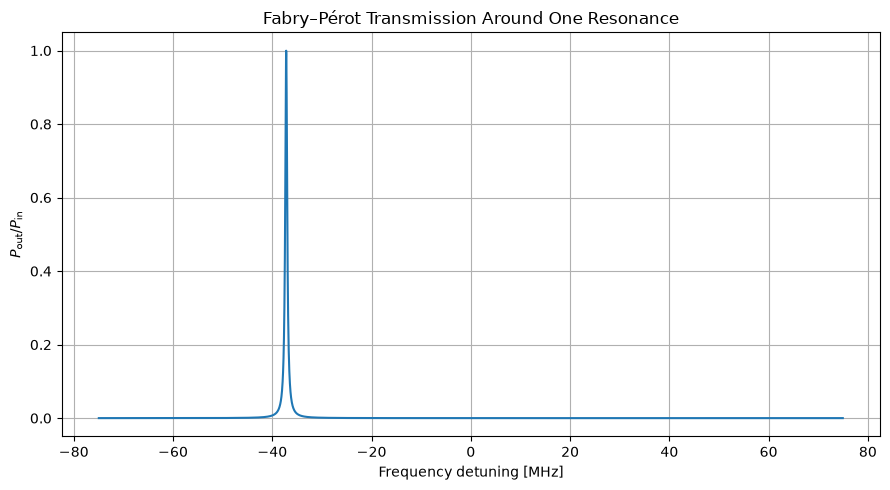

In [18]:
nu0 = c / wavelength

nu = np.linspace(
    nu0 - FSR/2,
    nu0 + FSR/2,
    5000
)

phi_nu = 4 * np.pi * nu * L / c

T_nu = cavity_transmission(
    phi_nu,
    R1,
    R2,
    T1,
    T2
)

plt.figure(figsize=(9, 5))
plt.plot((nu - nu0) / 1e6, T_nu)

plt.xlabel('Frequency detuning [MHz]')
plt.ylabel(r'$P_{\rm out}/P_{\rm in}$')
plt.title('Fabry–Pérot Transmission Around One Resonance')

plt.grid(True)
plt.tight_layout()
plt.show()

# 17. Output power versus input power

The cavity is a linear passive optical system, so at a fixed detuning

$$
P_{\rm out}\propto P_{\rm in}.
$$

For the ideal symmetric lossless cavity, the resonant transmitted power equals the incident power.

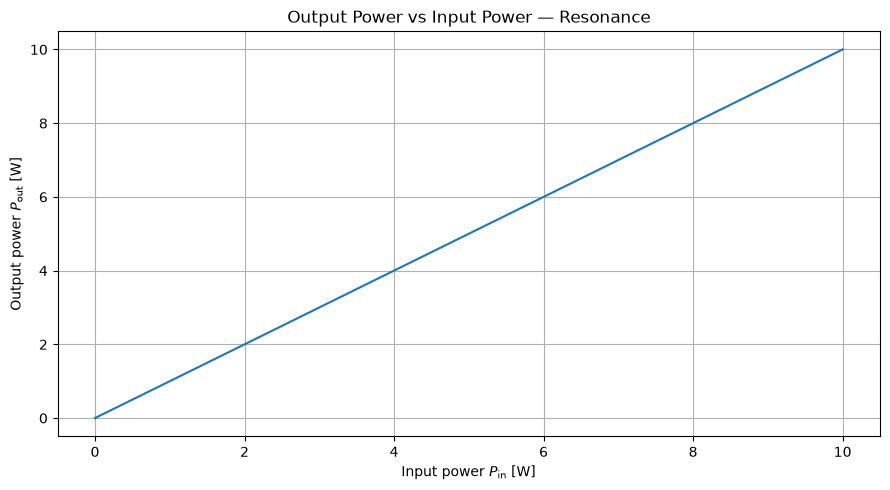

In [19]:
P_in_values = np.linspace(0, 10, 500)

# Symmetric, lossless cavity on resonance
P_out_values = P_in_values

plt.figure(figsize=(9, 5))
plt.plot(P_in_values, P_out_values)

plt.xlabel(r'Input power $P_{\rm in}$ [W]')
plt.ylabel(r'Output power $P_{\rm out}$ [W]')
plt.title('Output Power vs Input Power — Resonance')

plt.grid(True)
plt.tight_layout()
plt.show()

# 18. Intracavity power versus input power

At resonance,

$$
P_{\rm cav}=B_{\rm res}P_{\rm in}.
$$

Thus the intracavity power scales linearly with input power, but the proportionality factor can be very large for a high-finesse cavity.

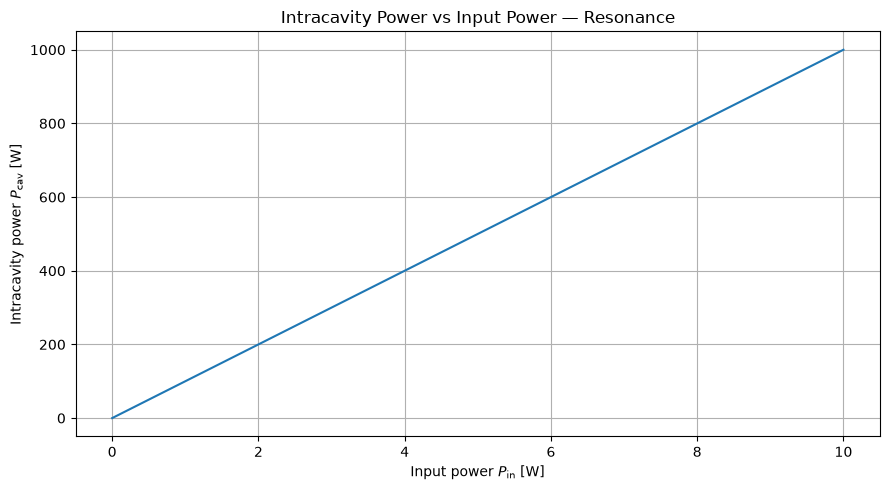

In [20]:
P_cav_values = B_res_analytical * P_in_values

plt.figure(figsize=(9, 5))
plt.plot(P_in_values, P_cav_values)

plt.xlabel(r'Input power $P_{\rm in}$ [W]')
plt.ylabel(r'Intracavity power $P_{\rm cav}$ [W]')
plt.title('Intracavity Power vs Input Power — Resonance')

plt.grid(True)
plt.tight_layout()
plt.show()

# 19. Unequal mirror reflectivities

Now consider

$$
R_1\neq R_2.
$$

The resonant buildup becomes

$$
\boxed{
B_{\rm res}
=
\frac{T_1}
{(1-\sqrt{R_1R_2})^2}
}.
$$

The resonant transmission becomes

$$
\boxed{
\frac{P_{\rm out}}{P_{\rm in}}
=
\frac{T_1T_2}
{(1-\sqrt{R_1R_2})^2}
}.
$$

This introduces the idea of input coupling and impedance matching.

In [21]:
R1_asym = 0.99
R2_asym = 0.999

T1_asym = 1 - R1_asym
T2_asym = 1 - R2_asym

B_res_asym = (
    T1_asym /
    (1 - np.sqrt(R1_asym * R2_asym))**2
)

T_res_asym = (
    T1_asym * T2_asym /
    (1 - np.sqrt(R1_asym * R2_asym))**2
)

P_cav_asym = B_res_asym * P_in
P_out_asym = T_res_asym * P_in

print('Asymmetric cavity')
print('-----------------')
print(f'R1 = {R1_asym}')
print(f'R2 = {R2_asym}')
print(f'Buildup = {B_res_asym:.6f}')
print(f'P_cav  = {P_cav_asym:.6f} W')
print(f'P_out  = {P_out_asym:.6f} W')
print(f'T_res  = {T_res_asym:.6f}')

Asymmetric cavity
-----------------
R1 = 0.99
R2 = 0.999
Buildup = 329.358035
P_cav  = 329.358035 W
P_out  = 0.329358 W
T_res  = 0.329358


# 20. Reflection from the cavity

The reflected field is the interference of:

1. The directly reflected input field.
2. The field leaking back through mirror 1.

For a lossless cavity, energy conservation requires

$$
R_{\rm cav}+T_{\rm cav}=1.
$$

Using the field reflection coefficient

$$
r_{\rm cav}
=
\frac{r_1-r_2e^{-i\phi}}
{1-r_1r_2e^{-i\phi}},
$$

the reflected power fraction is

$$
R_{\rm cav}=|r_{\rm cav}|^2.
$$

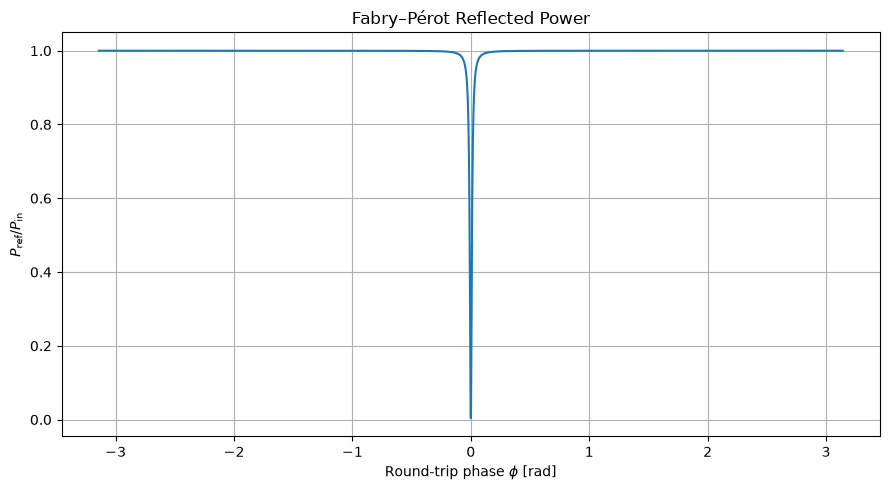

In [22]:
def cavity_reflection(phi, R1, R2):
    """Power reflection coefficient for a lossless cavity."""

    r1 = np.sqrt(R1)
    r2 = np.sqrt(R2)

    numerator = r1 - r2 * np.exp(-1j * phi)
    denominator = 1 - r1 * r2 * np.exp(-1j * phi)

    r_cav = numerator / denominator

    return np.abs(r_cav)**2


reflection = cavity_reflection(phi, R1, R2)

plt.figure(figsize=(9, 5))
plt.plot(phi, reflection)

plt.xlabel(r'Round-trip phase $\phi$ [rad]')
plt.ylabel(r'$P_{\rm ref}/P_{\rm in}$')
plt.title('Fabry–Pérot Reflected Power')

plt.grid(True)
plt.tight_layout()
plt.show()

# 21. Energy conservation check

For an ideal lossless cavity,

$$
P_{\rm ref}+P_{\rm trans}=P_{\rm in}.
$$

Therefore,

$$
\boxed{R_{\rm cav}+T_{\rm cav}=1}.
$$

We verify this numerically.

In [23]:
energy_error = np.max(
    np.abs(reflection + transmission - 1)
)

print(
    f'Maximum energy-conservation error = '
    f'{energy_error:.3e}'
)

Maximum energy-conservation error = 1.333e-12


# 22. Internal cavity loss

Real cavities have internal losses such as:

- absorption
- scattering
- imperfect coatings
- diffraction
- optical element losses

Introduce an internal round-trip **power transmission** factor $L_{\rm rt}$.

$$
0<L_{\rm rt}\leq1.
$$

The corresponding round-trip field factor is

$$
\sqrt{L_{\rm rt}}.
$$

The intracavity buildup becomes

$$
\boxed{
\frac{P_{\rm cav}}{P_{\rm in}}
=
\frac{T_1}
{1+R_1R_2L_{\rm rt}
-2\sqrt{R_1R_2L_{\rm rt}}\cos\phi}
}.
$$

This is particularly important for an OPO because the nonlinear crystal and other optical components introduce losses.

In [24]:
def cavity_buildup_with_loss(phi, R1, R2, T1, L_rt):
    """Intracavity buildup including internal round-trip loss."""

    denominator = (
        1
        + R1 * R2 * L_rt
        - 2 * np.sqrt(R1 * R2 * L_rt) * np.cos(phi)
    )

    return T1 / denominator


def cavity_transmission_with_loss(phi, R1, R2, T1, T2, L_rt):
    """Transmission including internal round-trip loss."""

    denominator = (
        1
        + R1 * R2 * L_rt
        - 2 * np.sqrt(R1 * R2 * L_rt) * np.cos(phi)
    )

    return T1 * T2 / denominator


L_rt = 0.98

B_loss = cavity_buildup_with_loss(
    phi, R1, R2, T1, L_rt
)

T_loss = cavity_transmission_with_loss(
    phi, R1, R2, T1, T2, L_rt
)

# 23. Effect of internal loss on buildup

Compare a cavity with no internal loss,

$$
L_{\rm rt}=1,
$$

with a lossy cavity,

$$
L_{\rm rt}<1.
$$

Even a small loss can significantly reduce the buildup of a high-finesse cavity.

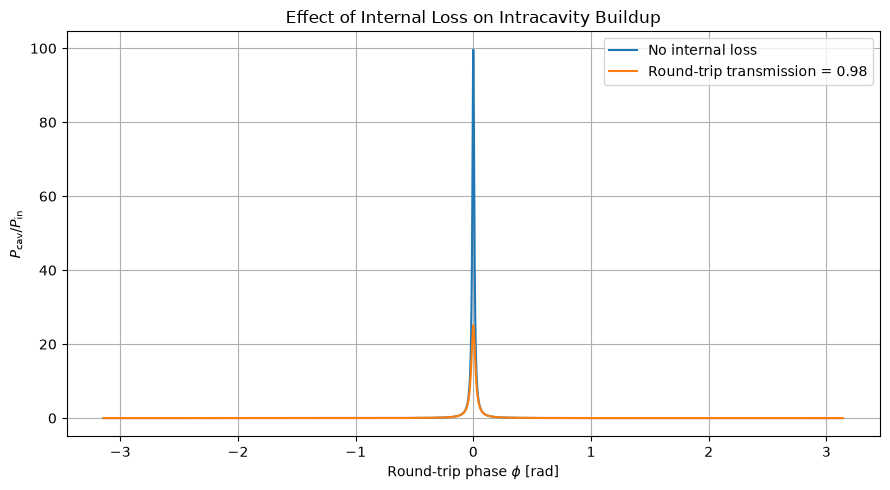

In [25]:
B_no_loss = cavity_buildup(phi, R1, R2, T1)

plt.figure(figsize=(9, 5))

plt.plot(phi, B_no_loss, label='No internal loss')
plt.plot(phi, B_loss, label=f'Round-trip transmission = {L_rt}')

plt.xlabel(r'Round-trip phase $\phi$ [rad]')
plt.ylabel(r'$P_{\rm cav}/P_{\rm in}$')
plt.title('Effect of Internal Loss on Intracavity Buildup')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 24. Parameter sweep: mirror reflectivity

We now compare resonance curves for several mirror reflectivities.

This connects

$$
\text{reflectivity}
\rightarrow
\text{buildup}
\rightarrow
\text{finesse}
\rightarrow
\text{linewidth}.
$$

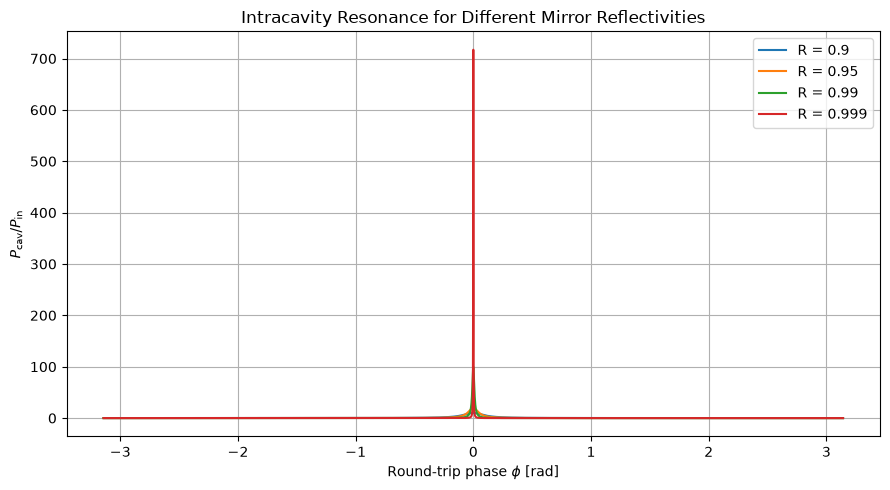

In [26]:
R_list = [0.90, 0.95, 0.99, 0.999]

plt.figure(figsize=(9, 5))

for R in R_list:
    T = 1 - R
    B_curve = cavity_buildup(phi, R, R, T)
    plt.plot(phi, B_curve, label=f'R = {R}')

plt.xlabel(r'Round-trip phase $\phi$ [rad]')
plt.ylabel(r'$P_{\rm cav}/P_{\rm in}$')
plt.title('Intracavity Resonance for Different Mirror Reflectivities')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 25. Parameter sweep: cavity length

The cavity length determines the FSR:

$$
\mathrm{FSR}=\frac{c}{2L}.
$$

In [27]:
length_list = [0.1, 0.5, 1.0, 2.0]

for length in length_list:
    fsr = c / (2 * length)
    print(
        f'L = {length:.2f} m  ->  '
        f'FSR = {fsr/1e6:.3f} MHz'
    )

L = 0.10 m  ->  FSR = 1498.962 MHz
L = 0.50 m  ->  FSR = 299.792 MHz
L = 1.00 m  ->  FSR = 149.896 MHz
L = 2.00 m  ->  FSR = 74.948 MHz


# 26. Parameter sweep: internal loss

We vary the internal round-trip transmission factor $L_{\rm rt}$.

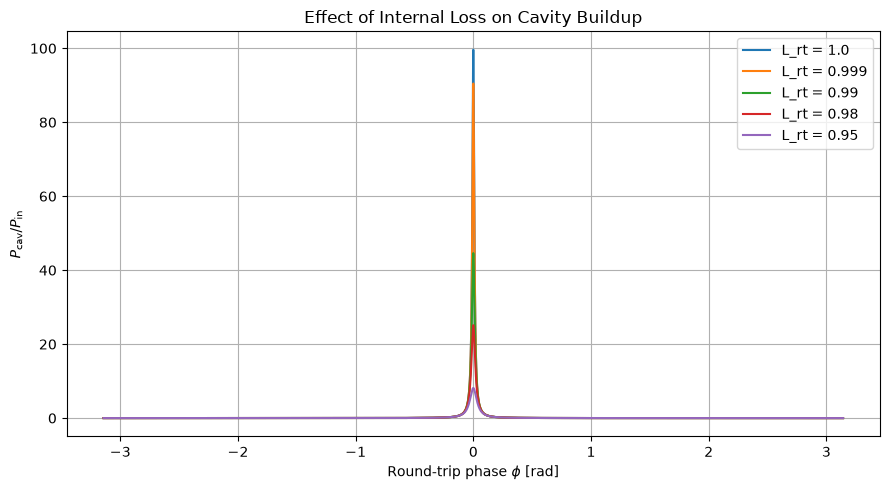

In [28]:
L_rt_list = [1.0, 0.999, 0.99, 0.98, 0.95]

plt.figure(figsize=(9, 5))

for Lrt in L_rt_list:
    B_curve = cavity_buildup_with_loss(
        phi, R1, R2, T1, Lrt
    )
    plt.plot(phi, B_curve, label=f'L_rt = {Lrt}')

plt.xlabel(r'Round-trip phase $\phi$ [rad]')
plt.ylabel(r'$P_{\rm cav}/P_{\rm in}$')
plt.title('Effect of Internal Loss on Cavity Buildup')

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 27. Analytical versus numerical result

At resonance, $\phi=0$.

We compare the analytical resonant buildup with the numerical evaluation of the full Airy expression.

In [29]:
phi_res = 0.0

B_analytical = (
    T1 /
    (1 - np.sqrt(R1 * R2))**2
)

B_numerical = cavity_buildup(
    phi_res,
    R1,
    R2,
    T1
)

print('Analytical result :', B_analytical)
print('Numerical result  :', B_numerical)
print(
    'Difference        :',
    abs(B_analytical - B_numerical)
)

Analytical result : 99.99999999999991
Numerical result  : 100.0000000000111
Difference        : 1.1183942660863977e-11


# 28. Analytical versus numerical transmission

We perform the same comparison for the transmitted power.

In [30]:
T_analytical = (
    T1 * T2 /
    (1 - np.sqrt(R1 * R2))**2
)

T_numerical = cavity_transmission(
    phi_res,
    R1,
    R2,
    T1,
    T2
)

print('Analytical transmission :', T_analytical)
print('Numerical transmission  :', T_numerical)
print(
    'Difference              :',
    abs(T_analytical - T_numerical)
)

Analytical transmission : 1.0
Numerical transmission  : 1.000000000000112
Difference              : 1.1191048088221578e-13


# 29. Summary of important equations

### Round-trip phase

$$
\boxed{\phi=\frac{4\pi\nu L}{c}}
$$

### Resonance condition

$$
\boxed{\phi=2\pi m}
$$

or

$$
\boxed{2L=m\lambda}
$$

### Free spectral range

$$
\boxed{\mathrm{FSR}=\frac{c}{2L}}
$$

### Intracavity buildup

$$
\boxed{
\frac{P_{\rm cav}}{P_{\rm in}}
=
\frac{T_1}
{1+R_1R_2-2\sqrt{R_1R_2}\cos\phi}
}
$$

### Resonant buildup

$$
\boxed{
B_{\rm res}
=
\frac{T_1}
{(1-\sqrt{R_1R_2})^2}
}
$$

### Symmetric lossless cavity

$$
\boxed{B_{\rm res}=\frac{1}{1-R}}
$$

### Transmitted power

$$
\boxed{
\frac{P_{\rm out}}{P_{\rm in}}
=
\frac{T_1T_2}
{1+R_1R_2-2\sqrt{R_1R_2}\cos\phi}
}
$$

### Finesse

$$
\boxed{
\mathcal{F}\approx\frac{\pi\sqrt{R}}{1-R}
}
$$

### Linewidth

$$
\boxed{\Delta\nu=\frac{\mathrm{FSR}}{\mathcal{F}}}
$$

# 30. Physical interpretation and conclusions

We have built a classical model of a Fabry–Pérot cavity.

The important physical picture is:

### Resonance

The round-trip phase determines whether successive circulating fields interfere constructively or destructively.

### Intracavity buildup

At resonance, constructive interference can produce a large circulating power compared with the incident power.

### Reflectivity

Higher mirror reflectivity generally gives higher buildup and higher finesse.

### Linewidth

Higher finesse corresponds to a narrower resonance linewidth.

### FSR

The FSR is primarily determined by cavity length.

### Loss

Internal loss limits the maximum achievable buildup.

### Important distinction

$$
\boxed{
\text{Cavity buildup}\neq\text{Optical gain}
}
$$

The cavity is passive. It does not generate optical energy.

The next stage will be to introduce Gaussian-beam propagation and then the nonlinear crystal.